In [ ]:
!pip install albumentations grad-cam --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 60.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from PIL import Image
import os, glob, random, copy
import pandas as pd
from google.colab import userdata

os.environ['KAGGLE_USERNAME'] = 'victorverissimo'
os.environ['KAGGLE_KEY']      = userdata.get('KAGGLE_API_KEY')

In [ ]:
if not os.path.exists('dataset_ceratocone'):
    os.system("kaggle datasets download -d elmehdi12/keratoconus-detection --force")
    os.system("unzip -q keratoconus-detection.zip -d dataset_ceratocone")
    if os.path.exists('keratoconus-detection.zip'):
        os.remove('keratoconus-detection.zip')
    print("Dataset pronto.")
else:
    print("Dataset já disponível.")

Dataset pronto.


In [ ]:
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASSES   = ['Normal', 'Suspect', 'Keratoconus']
CLASS_MAP = {'Normal': 0, 'Suspect': 1, 'Keratoconus': 2}
print(f"Rodando em: {device}")

Rodando em: cuda


In [ ]:
def scan_directory(root_path):
    data = []
    for cls_name in CLASSES:
        class_folder = os.path.join(root_path, cls_name)
        if not os.path.exists(class_folder):
            continue
        for case_id in sorted(os.listdir(class_folder)):
            case_path = os.path.join(class_folder, case_id)
            if not os.path.isdir(case_path): continue
            imgs = sorted(glob.glob(os.path.join(case_path, "*.jpg")))
            if len(imgs) >= 7:
                data.append((imgs, CLASS_MAP[cls_name], case_id))
    return data

BASE_DIR   = 'dataset_ceratocone'
PATH_TRAIN = os.path.join(BASE_DIR, 'Train_Validation sets', 'Train_Validation sets')
PATH_TEST  = os.path.join(BASE_DIR, 'Independent Test Set', 'Independent Test Set')

train_val_raw = scan_directory(PATH_TRAIN)
test_data     = scan_directory(PATH_TEST)

all_data = train_val_raw + test_data

train_data, test_data = train_test_split(
    all_data, test_size=0.2,
    stratify=[x[1] for x in all_data], random_state=42
)

train_data, val_data = train_test_split(
    train_data, test_size=0.2,
    stratify=[x[1] for x in train_data], random_state=42
)

BINARY_CLASS_MAP = {0: 0, 2: 1}  # Normal=0, KC=1

BINARY_CLASSES = ['Normal', 'Keratoconus']

train_data_binary = [(imgs, BINARY_CLASS_MAP[label], case_id)
                     for imgs, label, case_id in train_data if label != 1]
val_data_binary   = [(imgs, BINARY_CLASS_MAP[label], case_id)
                     for imgs, label, case_id in val_data if label != 1]
test_data_binary  = [(imgs, BINARY_CLASS_MAP[label], case_id)
                     for imgs, label, case_id in test_data if label != 1]

for split_name, split in [("Train_bin", train_data_binary),
                           ("Val_bin", val_data_binary),
                           ("Test_bin", test_data_binary)]:
    counts = {c: sum(1 for _,l,_ in split if l == i) for i,c in enumerate([0,1])}
    print(f"{split_name:10s} ({len(split)} pacientes): {counts}")

Train_bin  (256 pacientes): {0: 128, 1: 128}
Val_bin    (64 pacientes): {0: 32, 1: 32}
Test_bin   (80 pacientes): {0: 40, 1: 40}


In [ ]:
class MultiMapDataset(Dataset):
    """Dataset que funde 3 mapas topográficos em RGB"""
    MAP_TYPES = ['CT_A', 'Sag_A', 'Elv_P']

    def __init__(self, data_list, transform=None):
        self.data_list = data_list
        self.transform = transform

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        file_list, label, case_id = self.data_list[idx]
        channels = []

        for map_name in self.MAP_TYPES:
            path = next((s for s in file_list if map_name in s), None)
            assert path is not None, f"Mapa {map_name} não achado em {case_id}"
            img = np.array(Image.open(path).convert('L').resize((224, 224)))
            channels.append(img)

        merged = np.dstack(channels).astype(np.uint8)

        if self.transform:
            merged = self.transform(image=merged)['image']
        else:
            merged = ToTensorV2()(image=merged)['image']

        return merged, label, case_id

train_aug = A.Compose([
    A.Resize(224, 224),

    A.Rotate(limit=15, p=0.5),
    A.ElasticTransform(alpha=1, sigma=10, alpha_affine=10, p=0.3),

    A.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2,
        hue=0.1,
        p=0.5
    ),
    A.GaussianBlur(blur_limit=(3, 5), p=0.3),
    A.Sharpen(alpha=(0.1, 0.3), lightness=(0.8, 1.2), p=0.3),

    A.GaussNoise(var_limit=(5, 15), p=0.2),

    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_test_aug = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])


/tmp/ipykernel_195/343524986.py:35: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=1, sigma=10, alpha_affine=10, p=0.3),
/tmp/ipykernel_195/343524986.py:47: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5, 15), p=0.2),


In [ ]:
def get_model(arch: str, num_classes: int = None) -> nn.Module:
    if num_classes is None:
        num_classes = len(CLASSES)

    if arch == 'densenet121':
        model = models.densenet121(weights='IMAGENET1K_V1')
        in_f = model.classifier.in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_f, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    elif arch == 'efficientnet_b0':
        model = models.efficientnet_b0(weights='IMAGENET1K_V1')
        in_f = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_f, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    elif arch == 'resnet50':
        model = models.resnet50(weights='IMAGENET1K_V2')
        in_f = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_f, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    else:
        raise ValueError(f"Arquitetura desconhecida: {arch}")

    return model.to(device)

def freeze_backbone(model, arch):
    """Congela backbone para fase 1"""
    head = {'densenet121': 'classifier', 'efficientnet_b0': 'classifier', 'resnet50': 'fc'}[arch]
    for name, param in model.named_parameters():
        if not name.startswith(head):
            param.requires_grad = False

def unfreeze_all(model):
    """Descongela tudo para fase 2"""
    for param in model.parameters():
        param.requires_grad = True

In [ ]:
def run_epoch(model, loader, criterion, optimizer=None, phase='train'):
    """Executa uma época de treino ou validação"""
    is_training = (phase == 'train') and (optimizer is not None)
    model.train() if is_training else model.eval()

    running_loss, all_preds, all_labels = 0.0, [], []
    ctx = torch.enable_grad() if is_training else torch.no_grad()

    with ctx:
        for inputs, labels, _ in loader:
            inputs, labels = inputs.to(device), labels.to(device)

            if is_training:
                optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            if is_training:
                loss.backward()
                optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            all_preds.extend(outputs.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    return avg_loss, acc, f1

def train_model(arch, dataloaders,
                phase1_epochs=5, phase2_epochs=25,
                lr_phase1=1e-3, lr_phase2=1e-5, num_classes=2, save_suffix=''):
    """Treina modelo em 2 fases"""

    print(f"\n{'='*70}\n  MODELO: {arch.upper()}\n{'='*70}")

    model = get_model(arch, num_classes=num_classes)

    criterion = nn.CrossEntropyLoss()

    save_path = f'best_{arch}_pooled.pth'
    best_f1 = 0.0
    best_weights = None
    history = {k: [] for k in ['train_loss', 'val_loss',
                                'train_f1', 'val_f1',
                                'train_acc', 'val_acc']}

    print(f"\n  [FASE 1] Backbone congelado — {phase1_epochs} épocas (lr={lr_phase1})")
    freeze_backbone(model, arch)
    opt1 = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr_phase1,
        weight_decay=1e-4
    )

    for ep in range(1, phase1_epochs + 1):
        tl, ta, tf = run_epoch(model, dataloaders['train'], criterion, opt1, 'train')
        vl, va, vf = run_epoch(model, dataloaders['val'], criterion, phase='val')

        for k, v in zip(history.keys(), [tl, vl, tf, vf, ta, va]):
            history[k].append(v)

        marker = ''
        if vf > best_f1:
            best_f1 = vf
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, save_path)
            marker = '  BEST'

        print(f"  Ep {ep:02d}/{phase1_epochs} | Loss {tl:.4f}→{vl:.4f} | " f"F1 {tf:.4f}→{vf:.4f}{marker}")

    total = phase1_epochs + phase2_epochs
    print(f"\n  [FASE 2] Fine-tuning completo — {phase2_epochs} épocas (lr={lr_phase2})")
    unfreeze_all(model)
    opt2 = optim.AdamW(model.parameters(), lr=lr_phase2, weight_decay=1e-4)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=phase2_epochs, eta_min=1e-7)

    for ep in range(phase1_epochs + 1, total + 1):
        tl, ta, tf = run_epoch(model, dataloaders['train'], criterion, opt2, 'train')
        vl, va, vf = run_epoch(model, dataloaders['val'], criterion, phase='val')
        sched.step()

        for k, v in zip(history.keys(), [tl, vl, tf, vf, ta, va]):
            history[k].append(v)

        marker = ''
        if vf > best_f1:
            best_f1 = vf
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, save_path)
            marker = '  BEST'

        print(f"  Ep {ep:02d}/{total} | Loss {tl:.4f}→{vl:.4f} | "
              f"F1 {tf:.4f}→{vf:.4f}{marker}")

    print(f"\n  Melhor Val F1: {best_f1:.4f} → '{save_path}'")
    model.load_state_dict(best_weights)

    return model, history

In [ ]:
def evaluate_final(trained_models, dataloaders, test_data):
    """Avaliação final no test set"""
    print("\n" + "=" * 70)
    print("  AVALIAÇÃO FINAL NO TEST SET INDEPENDENTE")
    print("=" * 70)

    true_labels = [l for _, l, _ in test_data]

    results = {}
    for arch, model in trained_models.items():
        model.eval()
        preds = []

        with torch.no_grad():
            for inputs, labels, _ in dataloaders['test']:
                inputs = inputs.to(device)
                preds.extend(model(inputs).argmax(1).cpu().numpy())

        acc = accuracy_score(true_labels, preds)
        f1 = f1_score(true_labels, preds, average='macro', zero_division=0)

        results[arch] = {'acc': acc, 'f1': f1, 'preds': preds}

        print(f"\n  {arch.upper()}")
        print(f"  Accuracy:  {acc:.4f}")
        print(f"  F1-macro:  {f1:.4f}")
        print(f"\n{classification_report(true_labels, preds, labels=list(range(len(BINARY_CLASSES))), target_names=BINARY_CLASSES, zero_division=0)}")
        print(f"\nConfusion Matrix:")
        print(confusion_matrix(true_labels, preds))

    return results

In [ ]:
BATCH_SIZE = 24

train_ds = MultiMapDataset(train_data_binary, transform=train_aug)
val_ds = MultiMapDataset(val_data_binary, transform=val_test_aug)
test_ds = MultiMapDataset(test_data_binary, transform=val_test_aug)

dataloaders_binary = {
    'train': DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=2, pin_memory=True),
    'val': DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True),
    'test': DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True),
}

ARCHITECTURES = ['densenet121', 'efficientnet_b0', 'resnet50']
trained_models_binary, all_histories_binary = {}, {}

for arch in ARCHITECTURES:
    set_seed(42)
    model, history = train_model(
        arch, dataloaders_binary,
        num_classes=2,
        phase1_epochs=5, phase2_epochs=15,
        lr_phase1=1e-3, lr_phase2=1e-5,
        save_suffix='_binary'
    )
    trained_models_binary[arch] = model
    all_histories_binary[arch] = history

final_results = evaluate_final(trained_models_binary, dataloaders_binary, test_data_binary)


  MODELO: DENSENET121
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 63.3MB/s]



  [FASE 1] Backbone congelado — 5 épocas (lr=0.001)
  Ep 01/5 | Loss 0.5812→0.2714 | F1 0.6914→0.9531  BEST
  Ep 02/5 | Loss 0.4071→0.1423 | F1 0.8006→0.9687  BEST
  Ep 03/5 | Loss 0.3752→0.1080 | F1 0.8281→0.9687
  Ep 04/5 | Loss 0.3270→0.0990 | F1 0.8474→0.9687
  Ep 05/5 | Loss 0.3617→0.0798 | F1 0.8475→0.9844  BEST

  [FASE 2] Fine-tuning completo — 15 épocas (lr=1e-05)
  Ep 06/20 | Loss 0.3321→0.0743 | F1 0.8550→0.9844
  Ep 07/20 | Loss 0.2486→0.0609 | F1 0.8906→0.9844
  Ep 08/20 | Loss 0.2108→0.0526 | F1 0.8984→1.0000  BEST
  Ep 09/20 | Loss 0.2293→0.0497 | F1 0.9180→1.0000
  Ep 10/20 | Loss 0.2251→0.0463 | F1 0.8984→1.0000
  Ep 11/20 | Loss 0.1835→0.0443 | F1 0.9453→1.0000
  Ep 12/20 | Loss 0.1767→0.0422 | F1 0.9336→1.0000
  Ep 13/20 | Loss 0.1731→0.0382 | F1 0.9336→1.0000
  Ep 14/20 | Loss 0.2683→0.0373 | F1 0.9022→1.0000
  Ep 15/20 | Loss 0.2268→0.0367 | F1 0.9218→1.0000
  Ep 16/20 | Loss 0.1527→0.0359 | F1 0.9375→1.0000
  Ep 17/20 | Loss 0.2105→0.0379 | F1 0.9023→1.0000
  Ep 

100%|██████████| 20.5M/20.5M [00:00<00:00, 180MB/s]


  [FASE 1] Backbone congelado — 5 épocas (lr=0.001)


  Ep 01/5 | Loss 0.5626→0.3030 | F1 0.6995→0.9373  BEST
  Ep 02/5 | Loss 0.3273→0.1015 | F1 0.8516→0.9687  BEST
  Ep 03/5 | Loss 0.3398→0.1182 | F1 0.8554→0.9530
  Ep 04/5 | Loss 0.3635→0.0687 | F1 0.8435→0.9687
  Ep 05/5 | Loss 0.2677→0.0925 | F1 0.8750→0.9687

  [FASE 2] Fine-tuning completo — 15 épocas (lr=1e-05)
  Ep 06/20 | Loss 0.2858→0.0863 | F1 0.8827→0.9687
  Ep 07/20 | Loss 0.2745→0.0734 | F1 0.8710→0.9687
  Ep 08/20 | Loss 0.2763→0.0682 | F1 0.9062→0.9687
  Ep 09/20 | Loss 0.2148→0.0666 | F1 0.9141→0.9687
  Ep 10/20 | Loss 0.1951→0.0601 | F1 0.9140→0.9687
  Ep 11/20 | Loss 0.1810→0.0559 | F1 0.9336→0.9844  BEST
  Ep 12/20 | Loss 0.2858→0.0571 | F1 0.8789→0.9687
  Ep 13/20 | Loss 0.1941→0.0530 | F1 0.9062→1.0000  BEST
  Ep 14/20 | Loss 0.1744→0.0542 | F1 0.9219→0.9687
  Ep 15/20 | Loss 0.2349→0.0500 | F1 0.9023→1.0000
  Ep 16/20 | Loss 0.2342→0.0491 | F1 0.9101→0.9844
  Ep 17/20 | Loss 0.1879→0.0512 | F1 0.9336→0.9844
  Ep 18/20 | Loss 0.2024→0.0517 | F1 0.9023→1.0000
  Ep 19

100%|██████████| 97.8M/97.8M [00:00<00:00, 202MB/s]



  [FASE 1] Backbone congelado — 5 épocas (lr=0.001)
  Ep 01/5 | Loss 0.5869→0.3490 | F1 0.7304→0.9844  BEST
  Ep 02/5 | Loss 0.3995→0.1437 | F1 0.8470→1.0000  BEST
  Ep 03/5 | Loss 0.3065→0.1052 | F1 0.8905→0.9687
  Ep 04/5 | Loss 0.2904→0.0986 | F1 0.8746→0.9687
  Ep 05/5 | Loss 0.3397→0.1120 | F1 0.8789→0.9530

  [FASE 2] Fine-tuning completo — 15 épocas (lr=1e-05)
  Ep 06/20 | Loss 0.3581→0.0941 | F1 0.8627→0.9687
  Ep 07/20 | Loss 0.2398→0.0821 | F1 0.9060→0.9687
  Ep 08/20 | Loss 0.2134→0.0748 | F1 0.9098→0.9844
  Ep 09/20 | Loss 0.2348→0.0663 | F1 0.8748→0.9844
  Ep 10/20 | Loss 0.1812→0.0622 | F1 0.9258→0.9844
  Ep 11/20 | Loss 0.1925→0.0621 | F1 0.9258→0.9688
  Ep 12/20 | Loss 0.1832→0.0558 | F1 0.9180→0.9844
  Ep 13/20 | Loss 0.1443→0.0557 | F1 0.9531→0.9844
  Ep 14/20 | Loss 0.1520→0.0551 | F1 0.9492→0.9844
  Ep 15/20 | Loss 0.1640→0.0527 | F1 0.9297→0.9844
  Ep 16/20 | Loss 0.1538→0.0499 | F1 0.9375→0.9844
  Ep 17/20 | Loss 0.1321→0.0477 | F1 0.9492→0.9844
  Ep 18/20 | Loss

In [ ]:
def plot_learning_curves_combined(histories, save_name='curvas_exp3.png'):
    ARCHS = list(histories.keys())
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Curvas de Aprendizado', fontsize=18, fontweight='bold')

    for arch in ARCHS:
        history = histories[arch]
        epochs = range(1, len(history['train_loss']) + 1)
        axes[0][0].plot(epochs, history['train_acc'], label=arch.upper(), linewidth=2.5)
        axes[0][1].plot(epochs, history['val_acc'],   label=arch.upper(), linewidth=2.5)
        axes[1][0].plot(epochs, history['train_loss'], label=arch.upper(), linewidth=2.5)
        axes[1][1].plot(epochs, history['val_loss'],   label=arch.upper(), linewidth=2.5)

    titles = [('Training Accuracy', 'Acurácia'),
              ('Validation Accuracy', 'Acurácia'),
              ('Training Loss', 'Perda'),
              ('Validation Loss', 'Perda')]

    for ax, (title, ylabel) in zip(axes.flat, titles):
        ax.set_title(title, fontsize=15, fontweight='bold')
        ax.set_xlabel('Épocas', fontsize=13)
        ax.set_ylabel(ylabel, fontsize=13)
        ax.tick_params(axis='both', labelsize=12)
        ax.legend(fontsize=12)
        ax.grid(True, alpha=0.3)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(save_name, dpi=180, bbox_inches='tight')
    plt.show()

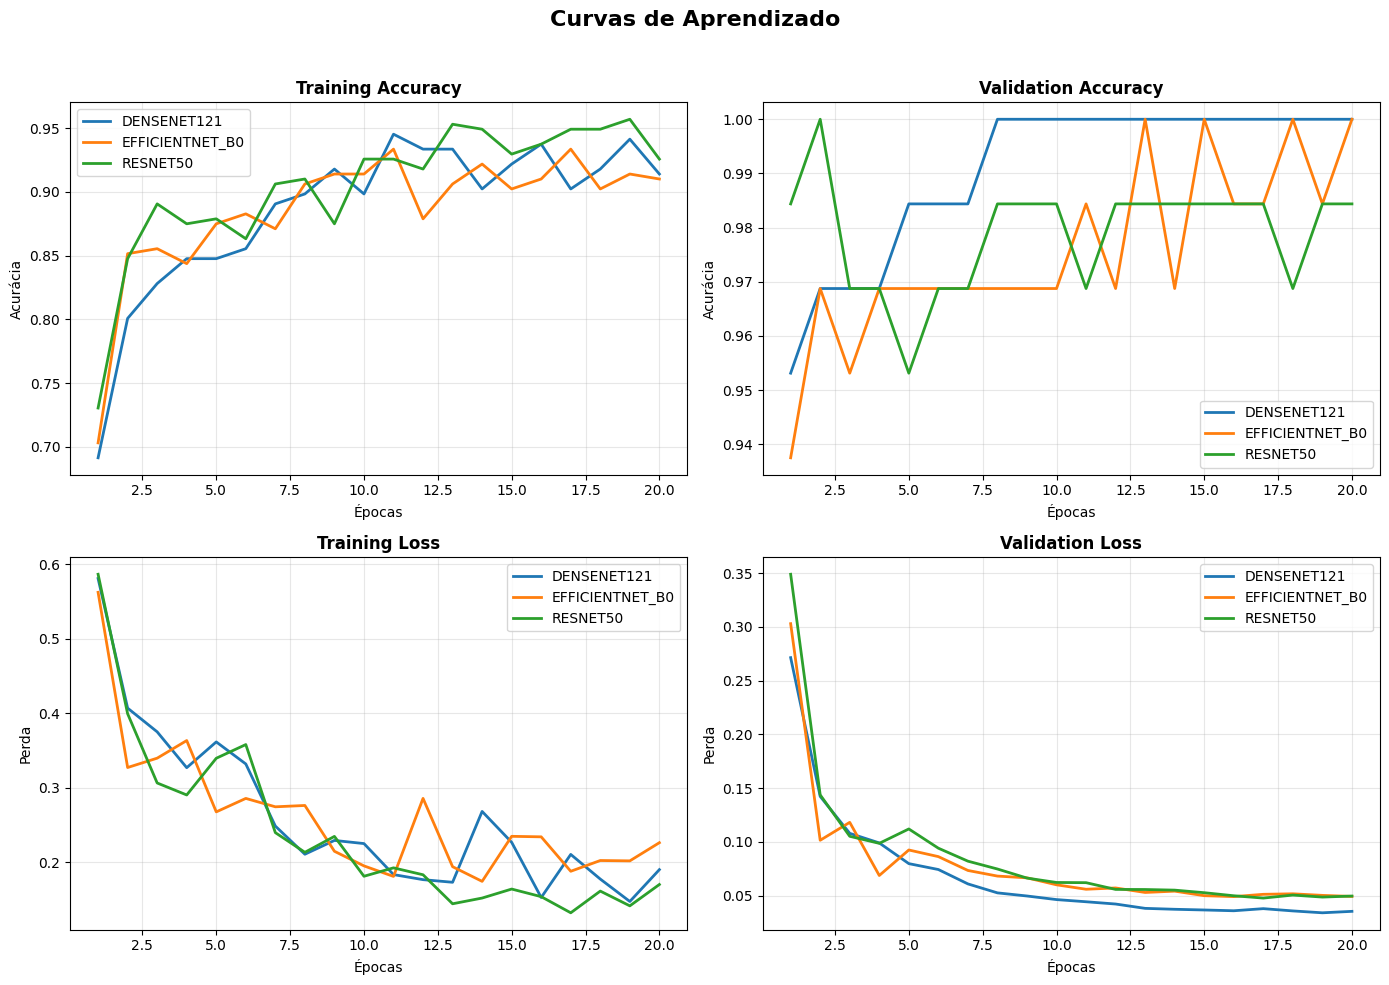

Salvo: curvas_exp3.png


In [ ]:
plot_learning_curves_combined(all_histories_binary, save_name='curvas_exp3.png')

In [ ]:
plot_confusion_matrices(
    trained_models_binary,
    dataloaders_binary,
    val_data_binary,
    test_data_binary,
    BINARY_CLASSES
)

NameError: name 'plot_confusion_matrices' is not defined

In [ ]:
from pytorch_grad_cam import GradCAM, ScoreCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

def get_target_layer(model, arch):
    """Retorna camada alvo para CAM de cada arquitetura"""
    if arch == 'densenet121':
        return [model.features.denseblock4.denselayer16.conv2]
    elif arch == 'efficientnet_b0':
        return [model.features[-1][0]]
    elif arch == 'resnet50':
        return [model.layer4[-1].conv3]
    else:
        raise ValueError(f"Arquitetura {arch} não suportada")

def generate_cam_ct_a(model, arch, data_list, sample_idx, CLASSES, val_test_aug, device):
    """
    Gera visualizações Grad-CAM e Score-CAM APENAS para CT_A
    Agora mostra o mapa COLORIDO original
    """

    model.eval()
    imgs_paths, true_label, case_id = data_list[sample_idx]

    path_ct_a = next((s for s in imgs_paths if 'CT_A' in s), None)
    if path_ct_a is None:
        print(f"⚠ CT_A não encontrado no caso {case_id}")
        return None

    img_original_color = np.array(Image.open(path_ct_a).resize((224, 224)))
    if len(img_original_color.shape) == 2:
        img_original_color = np.dstack([img_original_color]*3)
    img_original_color = img_original_color.astype(np.float32) / 255.0

    img_gray = np.array(Image.open(path_ct_a).convert('L').resize((224, 224)))
    img_rgb = np.dstack([img_gray, img_gray, img_gray]).astype(np.uint8)

    tensor = val_test_aug(image=img_rgb)['image'].unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(tensor)
        pred_lbl = logits.argmax(1).item()
        probs = torch.softmax(logits, dim=1)[0].cpu().numpy()

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_for_cam = (tensor[0].permute(1, 2, 0).cpu().numpy() * std + mean)
    img_for_cam = img_for_cam.clip(0, 1).astype(np.float32)

    target_layers = get_target_layer(model, arch)

    gradcam = GradCAM(model=model, target_layers=target_layers)
    with gradcam as cam:
        gc_map = cam(input_tensor=tensor,
                    targets=[ClassifierOutputTarget(pred_lbl)])[0]
        gradcam_vis = show_cam_on_image(img_for_cam, gc_map, use_rgb=True)

    scorecam = ScoreCAM(model=model, target_layers=target_layers)
    with scorecam as cam:
        sc_map = cam(input_tensor=tensor,
                    targets=[ClassifierOutputTarget(pred_lbl)])[0]
        scorecam_vis = show_cam_on_image(img_for_cam, sc_map, use_rgb=True)

    return {
        'case_id': case_id,
        'true_label': true_label,
        'pred_label': pred_lbl,
        'probs': probs,
        'img_original': img_original_color,
        'gradcam': gradcam_vis,
        'scorecam': scorecam_vis,
        'correct': (true_label == pred_lbl)
    }

def plot_cam_comparison(result, arch, CLASSES, save_path=None):
    """
    Plota comparação: Original | Grad-CAM | Score-CAM
    """

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    status = " CORRETO" if result['correct'] else " ERRADO"
    color = 'green' if result['correct'] else 'red'

    fig.suptitle(
        f"{arch.upper()} — Mapa CT_A (Espessura Corneana)\n"
        f"Caso: {result['case_id']} | "
        f"Real: {CLASSES[result['true_label']]}  |  "
        f"Predito: {CLASSES[result['pred_label']]} ({100*result['probs'][result['pred_label']]:.1f}%)  |  "
        f"{status}",fontsize=11, fontweight='bold', color=color
    )

    axes[0].imshow(result['img_original'])
    axes[0].set_title('CT_A Original', fontsize=10, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(result['gradcam'])
    axes[1].set_title(f"Grad-CAM\n(p={result['probs'][result['pred_label']]:.2f})",
                      fontsize=10, fontweight='bold')
    axes[1].axis('off')

    axes[2].imshow(result['scorecam'])
    axes[2].set_title(f"Score-CAM\n(p={result['probs'][result['pred_label']]:.2f})",
                      fontsize=10, fontweight='bold')
    axes[2].axis('off')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Salvo: {save_path}")

    plt.show()

def analyze_multiple_cases(model, arch, data_list, indices,
                           CLASSES, val_test_aug, device, output_dir='xai_results'):
    """
    Analisa múltiplos casos e salva visualizações

    Args:
        indices: Lista de índices para analisar
        output_dir: Diretório para salvar figuras
    """
    import os
    os.makedirs(output_dir, exist_ok=True)

    results = []

    for idx in indices:
        result = generate_cam_ct_a(model, arch, data_list, idx,
                                     CLASSES, val_test_aug, device)

        if result is not None:
            save_path = os.path.join(output_dir,
                                    f"cam_{arch}_case{idx}_{result['case_id']}.png")
            plot_cam_comparison(result, arch, CLASSES, save_path=save_path)

            results.append(result)

    return results

In [ ]:
def select_interesting_cases(model, arch, data_list, dataloaders_split,
                             CLASSES, n_correct=5, n_wrong=5):
    """
    Seleciona casos interessantes para análise manual:
    - n_correct casos corretamente classificados
    - n_wrong casos incorretamente classificados

    Returns:
        dict com índices dos casos selecionados
    """

    model.eval()

    true_labels = [l for _, l, _ in data_list]
    preds = []

    with torch.no_grad():
        for inputs, _, _ in dataloaders_split:
            preds.extend(model(inputs.to(device)).argmax(1).cpu().numpy())

    correct_indices = [i for i, (t, p) in enumerate(zip(true_labels, preds)) if t == p]
    wrong_indices = [i for i, (t, p) in enumerate(zip(true_labels, preds)) if t != p]

    import random
    random.seed(42)

    selected_correct = random.sample(correct_indices, min(n_correct, len(correct_indices)))
    selected_wrong = random.sample(wrong_indices, min(n_wrong, len(wrong_indices)))

    print(f"\n Selecionados {len(selected_correct)} casos corretos")
    print(f" Selecionados {len(selected_wrong)} casos errados")
    print(f"\nCasos corretos: {selected_correct}")
    print(f"Casos errados: {selected_wrong}")

    return {
        'correct': selected_correct,
        'wrong': selected_wrong,
        'all': selected_correct + selected_wrong
    }

In [ ]:
arch = 'resnet50'  # ou 'densenet121', 'efficientnet_b0'
model = trained_models_binary[arch]

selected = select_interesting_cases(
    model, arch, val_data_binary, dataloaders_binary['val'],
    BINARY_CLASSES, n_correct=5, n_wrong=5
)

results = analyze_multiple_cases(
    model, arch, val_data_binary, selected['all'],
    BINARY_CLASSES, val_test_aug, device,
    output_dir=f'xai_results_{arch}'
)

print(f"\n Análise completa! {len(results)} casos processados.")
print(f" Figuras salvas em: xai_results_{arch}/")